In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from PIL import Image
from pathlib import Path
import time

from brainvision.constants import *
from brainvision.models import (Baseline1DDNN, FabeloDNN, FabeloCNN,
                                 HuEtAl1DCNN, LeeEtAl2DCNN,
                                 HamidaEtAl3DCNN, HybridSN, SpectralFormer)
from brainvision.data.io import load_processed_patients, unzip_patient
from brainvision.utils import build_run_name

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
#                        CONFIGURE COMPARISON HERE
# ══════════════════════════════════════════════════════════════════════════════

# Fixed model configuration — loss functions are varied automatically
MODEL          = "1D-NN-Fabelo"      # model architecture to compare across
STRATEGY       = "vp_fabelo"   # validation strategy used during training
REDUCE_PIXELS  = True          # must match training
COMPARE_FOLD   = 1             # which fold's checkpoints to use

# Loss functions to compare — all four by default
LOSS_FNS = ["CE", "FL", "DL", "UFL"]

# Patients to generate comparison maps for
COMPARE_PATIENTS = [
    "004-02",
    "012-01",
]

In [19]:
PATCH_MODELS = {'2D-CNN', '2D-CNN-Fabelo', '3D-CNN', 'HybridSN'}

MODEL_REGISTRY = {
    '1D-NN'         : lambda: Baseline1DDNN(N_DECIMATED_BANDS, N_CLASSES,
                                             dropout=True,
                                             dropout_rate=DROPOUT_RATE),
    '1D-NN-Fabelo'  : lambda: FabeloDNN(N_DECIMATED_BANDS, N_CLASSES),
    '1D-CNN'        : lambda: HuEtAl1DCNN(N_DECIMATED_BANDS, N_CLASSES),
    '2D-CNN'        : lambda: LeeEtAl2DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                             PATCH_SIZE),
    '2D-CNN-Fabelo' : lambda: FabeloCNN(N_DECIMATED_BANDS, N_CLASSES,
                                         PATCH_SIZE),
    '3D-CNN'        : lambda: HamidaEtAl3DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                               PATCH_SIZE),
    'HybridSN'      : lambda: HybridSN(N_DECIMATED_BANDS, PATCH_SIZE,
                                        N_CLASSES),
    'SpectralFormer': lambda: SpectralFormer(N_DECIMATED_BANDS, N_CLASSES,
                                              near_band   = SF_NEAR_BAND,
                                              dim         = SF_DIM,
                                              depth       = SF_DEPTH,
                                              heads       = SF_HEADS,
                                              dim_head    = SF_DIM_HEAD,
                                              mlp_dim     = SF_MLP_DIM,
                                              dropout     = SF_DROPOUT,
                                              emb_dropout = SF_EMB_DROPOUT,
                                              mode        = SF_MODE),
}

LOSS_COLORS = {
    'CE'  : '#378ADD',
    'FL'  : '#D85A30',
    'DL'  : '#5DCAA5',
    'UFL' : '#7F77DD',
}

In [20]:
print(f"Model    : {MODEL}")
print(f"Strategy : {STRATEGY}  ({'bal' if REDUCE_PIXELS else 'nobal'})")
print(f"Fold     : {COMPARE_FOLD}")
print(f"\nCheckpoint availability:")

run_names       = {}
missing         = []

for loss_fn in LOSS_FNS:
    run_name = build_run_name(
        model         = MODEL,
        loss_fn       = loss_fn,
        strategy      = STRATEGY,
        fold          = COMPARE_FOLD,
        reduce_pixels = REDUCE_PIXELS,
    )
    ckpt_path = Path(CHECKPOINTS_DIR) / f"{run_name}.pt"
    exists    = ckpt_path.exists()
    tag       = "✅" if exists else "❌ MISSING"
    print(f"  {loss_fn:<6} {run_name}  {tag}")
    run_names[loss_fn] = run_name
    if not exists:
        missing.append(loss_fn)

if missing:
    print(f"\n⚠️  Missing checkpoints for: {missing}")
    print(f"   These loss functions will be skipped.")
else:
    print(f"\n✅ All checkpoints found — ready to compare")

Model    : 1D-NN-Fabelo
Strategy : vp_fabelo  (bal)
Fold     : 1

Checkpoint availability:
  CE     1dnnfabelo_ce_bal_fold1_vpfabelo  ✅
  FL     1dnnfabelo_fl_bal_fold1_vpfabelo  ✅
  DL     1dnnfabelo_dl_bal_fold1_vpfabelo  ✅
  UFL    1dnnfabelo_ufl_bal_fold1_vpfabelo  ✅

✅ All checkpoints found — ready to compare


In [21]:

# Load all models ───────────────────────────────────────────────────
def load_model(loss_fn: str) -> torch.nn.Module | None:
    """Load checkpoint for a given loss function."""
    run_name  = run_names[loss_fn]
    ckpt_path = Path(CHECKPOINTS_DIR) / f"{run_name}.pt"

    if not ckpt_path.exists():
        return None

    m = MODEL_REGISTRY[MODEL]().to(device)
    m.load_state_dict(
        torch.load(ckpt_path, map_location=device, weights_only=True)
    )
    m.eval()
    return m


models = {}
for loss_fn in LOSS_FNS:
    m = load_model(loss_fn)
    if m is not None:
        models[loss_fn] = m
        n_params = sum(p.numel() for p in m.parameters())
        print(f"  {loss_fn:<6} loaded  params={n_params:,}")

print(f"\n{len(models)} / {len(LOSS_FNS)} models loaded")

  CE     loaded  params=4,936
  FL     loaded  params=4,936
  DL     loaded  params=4,936
  UFL    loaded  params=4,936

4 / 4 models loaded


In [22]:
# ── Patient loader ────────────────────────────────────────────────────
def load_patient_for_viz(patient_id: str) -> dict | None:
    """Find and load a preprocessed patient by ID across all campaigns."""
    for campaign_id, data_dir in PROCESSED_DIRS.items():
        npz_path = Path(data_dir) / f"{patient_id}.npz"
        if not npz_path.exists():
            continue

        print(f"  Found {patient_id} in Campaign {campaign_id}")
        data       = np.load(npz_path)
        image_jpg  = None
        gt_map_jpg = None

        raw_zip = Path(CAMPAIGN_DIRS[campaign_id]) / f"{patient_id}.zip"
        if raw_zip.exists():
            try:
                result     = unzip_patient(str(raw_zip))
                folder     = result['folder'] if isinstance(result, dict) else result
                image_jpg  = folder / 'image.jpg'
                gt_map_jpg = folder / 'gtMap.jpg'
            except Exception as e:
                print(f"  ⚠️  Could not load JPEG previews: {e}")

        return {
            'id'        : patient_id,
            'processed' : data['processed'],
            'labels'    : data['labels'],
            'image'     : image_jpg,
            'gt_map'    : gt_map_jpg,
        }

    print(f"  ⚠️  Patient {patient_id} not found in any campaign")
    return None

In [23]:
# Inference ─────────────────────────────────────────────────────────
@torch.no_grad()
def predict_full_image(model: torch.nn.Module,
                       patient: dict) -> tuple[np.ndarray, dict]:
    """Run inference on all labelled pixels. Returns (pred_map, timing)."""
    cube      = patient['processed']
    label_map = patient['labels']
    H, W, C   = cube.shape
    pred_map  = np.full((H, W), -1, dtype=np.int32)
    mask      = label_map > 0
    n_pixels  = mask.sum()

    t_start = time.perf_counter()

    if MODEL in PATCH_MODELS:
        half   = PATCH_SIZE // 2
        padded = np.pad(cube, ((half,half),(half,half),(0,0)),
                        mode='reflect').astype(np.float32)
        ys, xs     = np.where(mask)
        all_preds  = []
        batch_size = 512

        for start in range(0, len(ys), batch_size):
            batch_ys = ys[start:start+batch_size]
            batch_xs = xs[start:start+batch_size]
            patches  = np.stack([
                padded[y:y+PATCH_SIZE, x:x+PATCH_SIZE, :].transpose(2,0,1)
                for y, x in zip(batch_ys, batch_xs)
            ]).astype(np.float32)
            logits = model(torch.tensor(patches).to(device))
            all_preds.extend(logits.argmax(1).cpu().numpy())

        for y, x, p in zip(ys, xs, all_preds):
            pred_map[y, x] = p

    else:
        pixels      = cube.reshape(-1, C).astype(np.float32)
        flat_labels = label_map.reshape(-1)
        flat_mask   = flat_labels > 0
        labelled_px = pixels[flat_mask]
        preds       = []
        bs          = 4096

        for start in range(0, len(labelled_px), bs):
            logits = model(torch.tensor(
                labelled_px[start:start+bs]).to(device))
            preds.extend(logits.argmax(1).cpu().numpy())

        flat_pred            = np.full(H * W, -1, dtype=np.int32)
        flat_pred[flat_mask] = preds
        pred_map             = flat_pred.reshape(H, W)

    t_end      = time.perf_counter()
    elapsed_ms = (t_end - t_start) * 1000

    timing = {
        'total_ms'       : elapsed_ms,
        'total_s'        : elapsed_ms / 1000,
        'n_pixels'       : int(n_pixels),
        'ms_per_pixel'   : elapsed_ms / n_pixels if n_pixels > 0 else 0,
        'pixels_per_sec' : n_pixels / (elapsed_ms / 1000) if elapsed_ms > 0 else 0,
    }

    return pred_map, timing

In [24]:
# ── Per-patient comparison plot ───────────────────────────────────────
TISSUE_COLORS = ['#5DCAA5', '#D85A30', '#378ADD', '#888780']
CMAP_TISSUE   = ListedColormap(['white'] + TISSUE_COLORS)
CMAP_AGREE    = ListedColormap(['#DDDDDD', '#5DCAA5', '#D85A30'])


def compute_class_accuracies(label_map: np.ndarray,
                              pred_map:  np.ndarray) -> dict:
    """Per-class accuracy for a single prediction map."""
    accs = {}
    for i, cls in enumerate(['NT', 'TT', 'BV', 'BG']):
        gt_mask     = (label_map - 1) == i
        correct     = ((pred_map == i) & gt_mask).sum()
        total       = gt_mask.sum()
        accs[cls]   = correct / total * 100 if total > 0 else 0.0
    return accs


def plot_loss_comparison(patient: dict,
                          pred_maps: dict[str, np.ndarray],
                          timings:   dict[str, dict]):
    """
    Grid comparison of all loss functions for one patient.

    Rows:
      1. Prediction maps
      2. Agreement maps (correct / incorrect)

    Columns:
      GT | CE | FL | DL | UFL  (+ RGB if available)
    """
    label_map = patient['labels']
    H, W      = label_map.shape
    mask      = label_map > 0
    gt_display = label_map.astype(float) - 1

    available_losses = [l for l in LOSS_FNS if l in pred_maps]
    has_rgb = (patient['image'] is not None and
               Path(patient['image']).exists())

    n_cols = 1 + len(available_losses) + (1 if has_rgb else 0)
    fig, axes = plt.subplots(2, n_cols, figsize=(4.5 * n_cols, 9))
    fig.suptitle(
        f"Loss Function Comparison — Patient {patient['id']}\n"
        f"Model: {MODEL}  |  Strategy: {STRATEGY}  |  "
        f"{'Balanced' if REDUCE_PIXELS else 'Unbalanced'}  |  "
        f"Fold {COMPARE_FOLD}",
        fontsize=12
    )

    col = 0

    # ── RGB preview ───────────────────────────────────────────────────────────
    if has_rgb:
        rgb = np.array(Image.open(patient['image']).convert('RGB'))
        axes[0, col].imshow(rgb)
        axes[0, col].set_title("RGB Preview", fontsize=10)
        axes[0, col].axis('off')
        axes[1, col].imshow(rgb)
        axes[1, col].axis('off')
        col += 1

    # ── Ground truth column ───────────────────────────────────────────────────
    axes[0, col].imshow(gt_display, cmap=CMAP_TISSUE, vmin=-1, vmax=3)
    axes[0, col].set_title("Ground Truth", fontsize=10)
    axes[0, col].axis('off')
    axes[1, col].axis('off')
    axes[1, col].text(0.5, 0.5, "Ground\nTruth",
                      ha='center', va='center',
                      transform=axes[1, col].transAxes,
                      fontsize=10, color='gray')
    col += 1

    # ── One column per loss function ──────────────────────────────────────────
    for loss_fn in available_losses:
        pred_map   = pred_maps[loss_fn]
        timing     = timings[loss_fn]
        accs       = compute_class_accuracies(label_map, pred_map)

        total      = mask.sum()
        correct    = ((pred_map == (label_map - 1)) & mask).sum()
        overall_acc = correct / total * 100 if total > 0 else 0

        agree_map  = np.zeros((H, W), dtype=np.float32)
        agree_map[mask & (pred_map == (label_map - 1))] = 1
        agree_map[mask & (pred_map != (label_map - 1))] = 2

        # ── Row 0: prediction map ─────────────────────────────────────────────
        axes[0, col].imshow(pred_map.astype(float),
                            cmap=CMAP_TISSUE, vmin=-1, vmax=3)
        axes[0, col].set_title(
            f"{loss_fn}\nOA={overall_acc:.1f}%  TT={accs['TT']:.1f}%",
            fontsize=10,
            color=LOSS_COLORS.get(loss_fn, 'black')
        )
        axes[0, col].axis('off')

        # ── Row 1: agreement map + timing ─────────────────────────────────────
        axes[1, col].imshow(agree_map, cmap=CMAP_AGREE, vmin=0, vmax=2)
        axes[1, col].axis('off')

        timing_str = (f"{timing['total_ms']:.0f}ms  "
                      f"({timing['pixels_per_sec']:,.0f} px/s)")
        axes[1, col].set_title(timing_str, fontsize=8, color='gray')

        col += 1

    # ── Shared legend ─────────────────────────────────────────────────────────
    legend_patches = [
        mpatches.Patch(color=c, label=CLASS_NAMES_SHORT[i+1])
        for i, c in enumerate(TISSUE_COLORS)
    ] + [
        mpatches.Patch(color='white',   label='Unlabelled',
                       linewidth=0.5,   edgecolor='gray'),
        mpatches.Patch(color='#5DCAA5', label='Correct'),
        mpatches.Patch(color='#D85A30', label='Incorrect'),
    ]
    fig.legend(handles=legend_patches, loc='lower center',
               ncol=len(legend_patches), fontsize=9,
               bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    out_path = (f"{RESULTS_DIR}/{MODEL.lower().replace('-','')}_{STRATEGY}_"
                f"fold{COMPARE_FOLD}_loss_comparison_{patient['id']}.png")
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {out_path}")

In [25]:
# ── Summary table across loss functions ───────────────────────────────
def print_comparison_table(patient:   dict,
                            pred_maps: dict[str, np.ndarray],
                            timings:   dict[str, dict]):
    """Print per-class accuracy and timing for all loss functions."""
    label_map = patient['labels']
    mask      = label_map > 0
    total     = mask.sum()

    print(f"\n{'═'*72}")
    print(f"  Comparison table — Patient {patient['id']}  |  Model: {MODEL}")
    print(f"{'═'*72}")
    print(f"  {'Loss':<6} {'OA':>7} {'NT':>7} {'TT':>7} {'BV':>7} "
          f"{'BG':>7}  {'Time (ms)':>10}  {'px/s':>10}")
    print(f"  {'─'*70}")

    for loss_fn in LOSS_FNS:
        if loss_fn not in pred_maps:
            print(f"  {loss_fn:<6} {'—':>7} {'—':>7} {'—':>7} "
                  f"{'—':>7} {'—':>7}  {'missing':>10}")
            continue

        pred_map  = pred_maps[loss_fn]
        timing    = timings[loss_fn]
        accs      = compute_class_accuracies(label_map, pred_map)
        correct   = ((pred_map == (label_map - 1)) & mask).sum()
        oa        = correct / total * 100 if total > 0 else 0

        tt_marker = "  ★" if accs['TT'] == max(
            compute_class_accuracies(label_map, pred_maps[l])['TT']
            for l in pred_maps
        ) else ""

        print(f"  {loss_fn:<6} {oa:>6.1f}% {accs['NT']:>6.1f}% "
              f"{accs['TT']:>6.1f}%{tt_marker:<3} {accs['BV']:>6.1f}% "
              f"{accs['BG']:>6.1f}%  "
              f"{timing['total_ms']:>10.1f}  "
              f"{timing['pixels_per_sec']:>10,.0f}")

    print(f"  {'─'*70}")
    print(f"  ★ = best TT sensitivity")

    # Clinical constraint check
    print(f"\n  Real-time constraint check (<60s per image):")
    for loss_fn, timing in timings.items():
        status = "✅" if timing['total_s'] < 60 else "❌"
        print(f"    {loss_fn:<6} {timing['total_s']:.2f}s  {status}")

In [26]:
def plot_sensitivity_comparison(patient:   dict,
                                 pred_maps: dict[str, np.ndarray]):
    """
    Bar chart comparing per-class sensitivity across all loss functions.
    TT bar is highlighted as the clinical priority class.
    """
    label_map        = patient['labels']
    available_losses = [l for l in LOSS_FNS if l in pred_maps]
    classes          = ['NT', 'TT', 'BV', 'BG']
    n_classes        = len(classes)
    n_losses         = len(available_losses)

    # Compute sensitivity per class per loss function
    sens = {loss_fn: {} for loss_fn in available_losses}
    for loss_fn in available_losses:
        pred_map = pred_maps[loss_fn]
        for i, cls in enumerate(classes):
            gt_mask      = (label_map - 1) == i
            tp           = ((pred_map == i) & gt_mask).sum()
            fn           = ((pred_map != i) & gt_mask).sum()
            sens[loss_fn][cls] = tp / (tp + fn + 1e-6) * 100

    # ── Bar chart ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"Sensitivity Comparison — Patient {patient['id']}\n"
        f"Model: {MODEL}  |  Strategy: {STRATEGY}  |  Fold {COMPARE_FOLD}",
        fontsize=12
    )

    x      = np.arange(n_classes)
    width  = 0.8 / n_losses
    offset = np.linspace(-(n_losses - 1) / 2, (n_losses - 1) / 2, n_losses) * width

    # ── Plot 1: Grouped bar chart — all classes ───────────────────────────────
    ax = axes[0]
    for i, loss_fn in enumerate(available_losses):
        values = [sens[loss_fn][cls] for cls in classes]
        bars   = ax.bar(x + offset[i], values, width,
                        label=loss_fn,
                        color=LOSS_COLORS.get(loss_fn, '#888780'),
                        alpha=0.85)
        # Value labels on bars
        for bar, val in zip(bars, values):
            if val > 3:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.5,
                        f'{val:.1f}', ha='center', va='bottom',
                        fontsize=7, rotation=90)

    # Highlight TT column
    ax.axvspan(x[1] - 0.45, x[1] + 0.45,
               alpha=0.08, color='#D85A30', zorder=0)
    ax.text(x[1], -8, '← clinical\n   priority',
            ha='center', fontsize=8, color='#D85A30')

    ax.set_xticks(x)
    ax.set_xticklabels([CLASS_NAMES_SHORT[i+1] for i in range(n_classes)])
    ax.set_ylabel("Sensitivity (%)")
    ax.set_ylim(0, 115)
    ax.set_title("Per-class sensitivity")
    ax.legend(title="Loss function")
    ax.grid(axis='y', alpha=0.3)

    # ── Plot 2: TT sensitivity focus — horizontal bar ─────────────────────────
    ax = axes[1]
    tt_values  = [sens[loss_fn]['TT'] for loss_fn in available_losses]
    bar_colors = [LOSS_COLORS.get(l, '#888780') for l in available_losses]
    bars       = ax.barh(available_losses, tt_values,
                         color=bar_colors, alpha=0.85)

    # Value labels
    for bar, val in zip(bars, tt_values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=10)

    # Mark the best
    best_idx = int(np.argmax(tt_values))
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)
    ax.text(tt_values[best_idx] + 0.5,
            best_idx + 0.35, '★ best', fontsize=8)

    ax.set_xlabel("TT Sensitivity (%)")
    ax.set_xlim(0, max(tt_values) * 1.25 + 5)
    ax.set_title("Tumour Tissue (TT) sensitivity\n"
                 "— clinical priority class")
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    out_path = (f"{RESULTS_DIR}/{MODEL.lower().replace('-','')}_{STRATEGY}_"
                f"fold{COMPARE_FOLD}_sensitivity_{patient['id']}.png")
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {out_path}")

    # ── Printed sensitivity table ──────────────────────────────────────────────
    print(f"\n  Sensitivity (%) — Patient {patient['id']}")
    print(f"  {'Loss':<6} {'NT':>8} {'TT':>8} {'BV':>8} {'BG':>8}  {'Mean':>8}")
    print(f"  {'─'*50}")
    for loss_fn in available_losses:
        values = [sens[loss_fn][cls] for cls in classes]
        mean   = np.mean(values)
        tt_tag = "  ★" if loss_fn == available_losses[
            int(np.argmax([sens[l]['TT'] for l in available_losses]))] else ""
        print(f"  {loss_fn:<6} "
              f"{values[0]:>7.1f}% "
              f"{values[1]:>7.1f}%{tt_tag:<3} "
              f"{values[2]:>7.1f}% "
              f"{values[3]:>7.1f}%  "
              f"{mean:>7.1f}%")
    print(f"  ★ = best TT sensitivity")


════════════════════════════════════════════════════════════
  Loss comparison — 1D-NN-Fabelo × vp_fabelo
  Fold 1  |  Balanced
════════════════════════════════════════════════════════════

── 004-02 ─────────────────────────────────────────────
  Found 004-02 in Campaign 1
  Image shape : (389, 345, 128)
  Running inference — CE... 15ms
  Running inference — FL... 3ms
  Running inference — DL... 3ms
  Running inference — UFL... 3ms


/var/folders/cv/jm24bgtx0qz01hhr4g1v99mh0000gn/T/ipykernel_6066/3281202739.py:113: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='white',   label='Unlabelled',


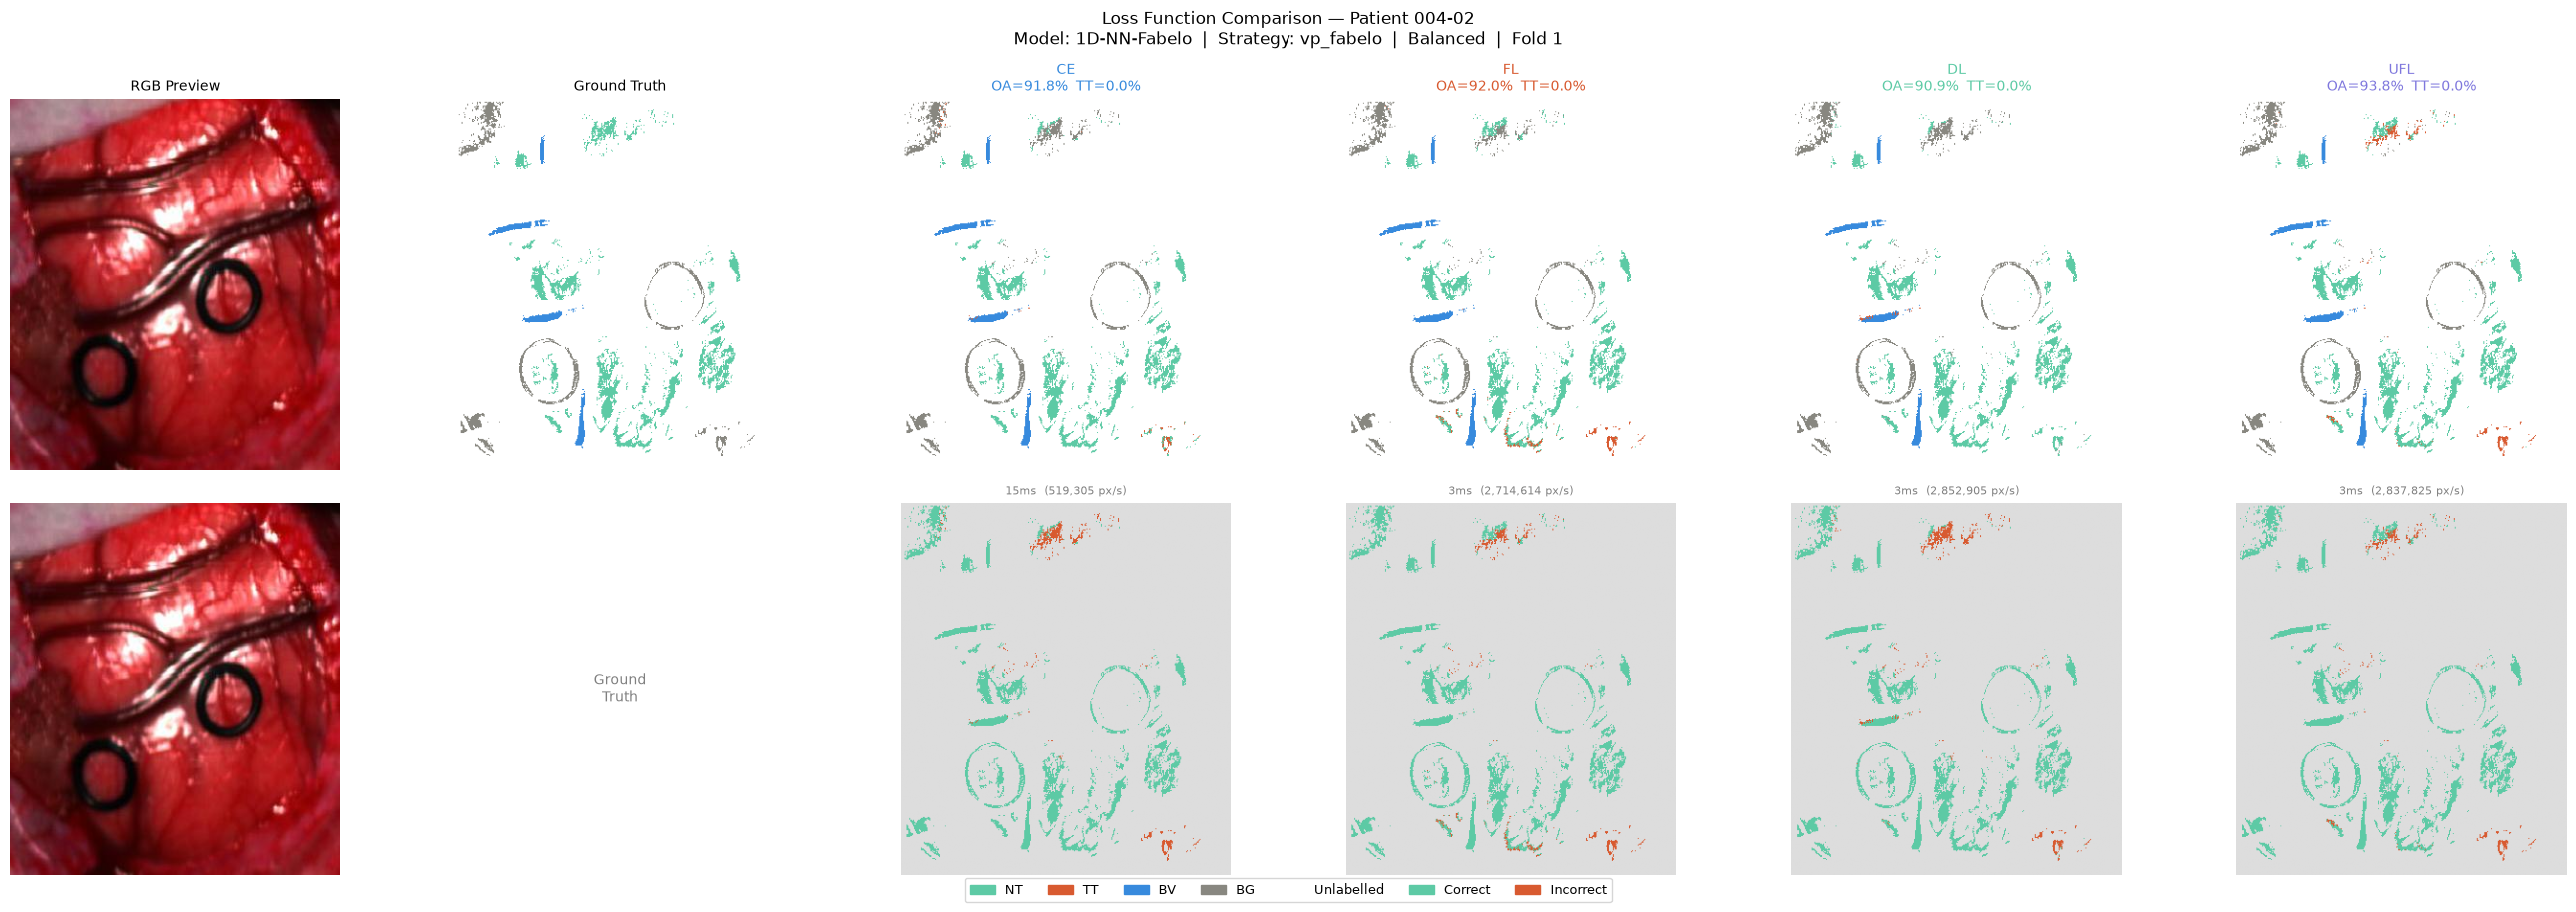

  Saved → ../results/1dnnfabelo_vp_fabelo_fold1_loss_comparison_004-02.png

════════════════════════════════════════════════════════════════════════
  Comparison table — Patient 004-02  |  Model: 1D-NN-Fabelo
════════════════════════════════════════════════════════════════════════
  Loss        OA      NT      TT      BV      BG   Time (ms)        px/s
  ──────────────────────────────────────────────────────────────────────
  CE       91.8%   90.9%    0.0%  ★   98.7%   90.7%        15.3     519,305
  FL       92.0%   90.7%    0.0%  ★   99.9%   91.7%         2.9   2,714,614
  DL       90.9%   89.7%    0.0%  ★   95.6%   91.4%         2.8   2,852,905
  UFL      93.8%   93.5%    0.0%  ★   99.7%   91.7%         2.8   2,837,825
  ──────────────────────────────────────────────────────────────────────
  ★ = best TT sensitivity

  Real-time constraint check (<60s per image):
    CE     0.02s  ✅
    FL     0.00s  ✅
    DL     0.00s  ✅
    UFL    0.00s  ✅


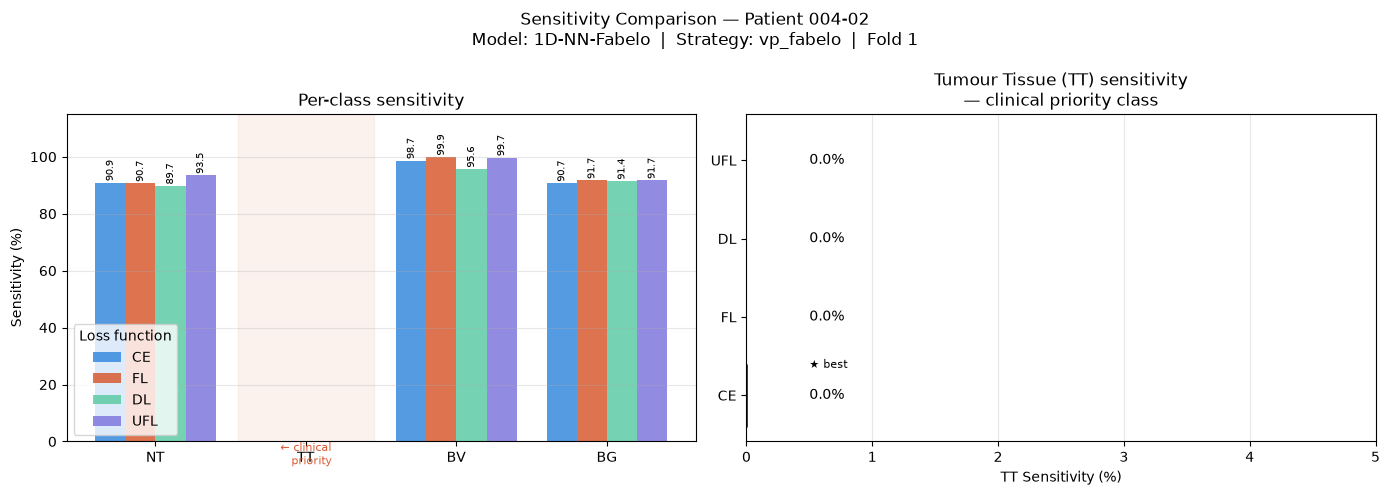

  Saved → ../results/1dnnfabelo_vp_fabelo_fold1_sensitivity_004-02.png

  Sensitivity (%) — Patient 004-02
  Loss         NT       TT       BV       BG      Mean
  ──────────────────────────────────────────────────
  CE        90.9%     0.0%  ★    98.7%    90.7%     70.1%
  FL        90.7%     0.0%       99.9%    91.7%     70.6%
  DL        89.7%     0.0%       95.6%    91.4%     69.2%
  UFL       93.5%     0.0%       99.7%    91.7%     71.2%
  ★ = best TT sensitivity

── 012-01 ─────────────────────────────────────────────
  Found 012-01 in Campaign 1
  Image shape : (443, 497, 128)
  Running inference — CE... 15ms
  Running inference — FL... 11ms
  Running inference — DL... 6ms
  Running inference — UFL... 5ms


/var/folders/cv/jm24bgtx0qz01hhr4g1v99mh0000gn/T/ipykernel_6066/3281202739.py:113: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='white',   label='Unlabelled',


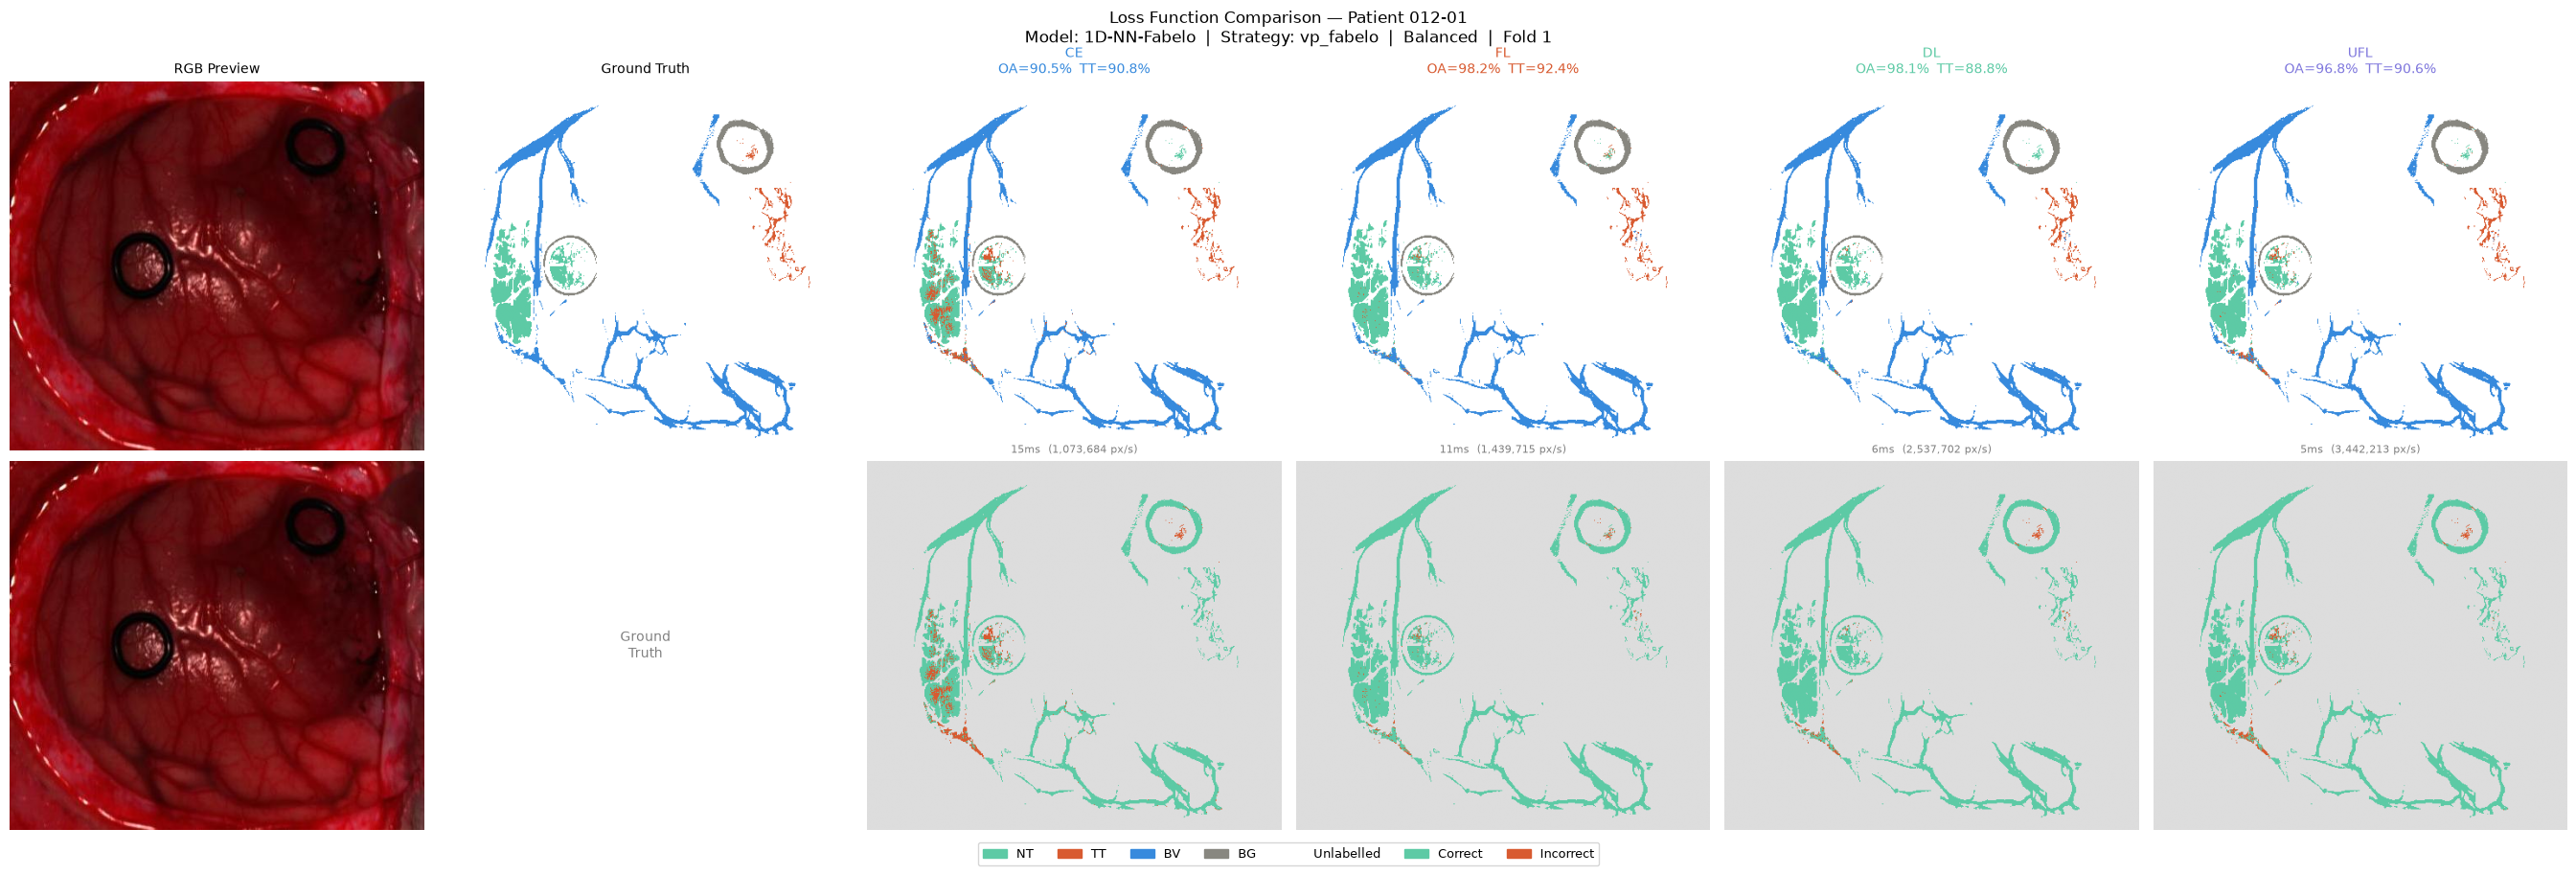

  Saved → ../results/1dnnfabelo_vp_fabelo_fold1_loss_comparison_012-01.png

════════════════════════════════════════════════════════════════════════
  Comparison table — Patient 012-01  |  Model: 1D-NN-Fabelo
════════════════════════════════════════════════════════════════════════
  Loss        OA      NT      TT      BV      BG   Time (ms)        px/s
  ──────────────────────────────────────────────────────────────────────
  CE       90.5%   79.7%   90.8%      94.5%   99.1%        14.7   1,073,684
  FL       98.2%   98.1%   92.4%  ★   98.7%   99.1%        10.9   1,439,715
  DL       98.1%   99.4%   88.8%      98.1%   98.9%         6.2   2,537,702
  UFL      96.8%   97.1%   90.6%      96.8%   98.8%         4.6   3,442,213
  ──────────────────────────────────────────────────────────────────────
  ★ = best TT sensitivity

  Real-time constraint check (<60s per image):
    CE     0.01s  ✅
    FL     0.01s  ✅
    DL     0.01s  ✅
    UFL    0.00s  ✅


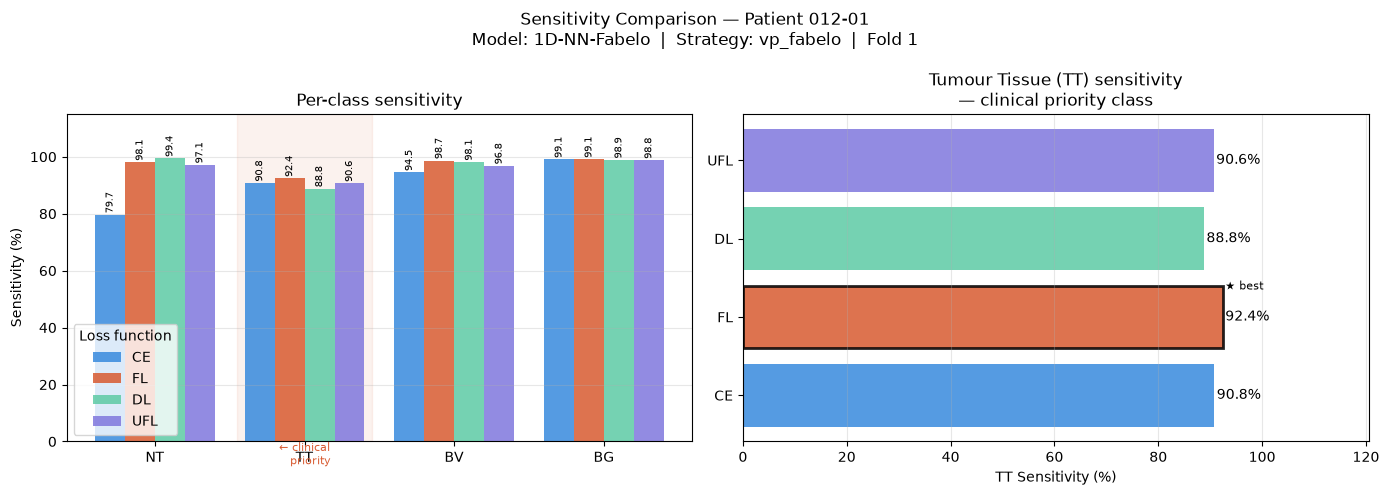

  Saved → ../results/1dnnfabelo_vp_fabelo_fold1_sensitivity_012-01.png

  Sensitivity (%) — Patient 012-01
  Loss         NT       TT       BV       BG      Mean
  ──────────────────────────────────────────────────
  CE        79.7%    90.8%       94.5%    99.1%     91.0%
  FL        98.1%    92.4%  ★    98.7%    99.1%     97.1%
  DL        99.4%    88.8%       98.1%    98.9%     96.3%
  UFL       97.1%    90.6%       96.8%    98.8%     95.8%
  ★ = best TT sensitivity


In [27]:
# ── Run comparison for all patients ──────────────────────────────────
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

print(f"\n{'═'*60}")
print(f"  Loss comparison — {MODEL} × {STRATEGY}")
print(f"  Fold {COMPARE_FOLD}  |  "
      f"{'Balanced' if REDUCE_PIXELS else 'Unbalanced'}")
print(f"{'═'*60}")

for patient_id in COMPARE_PATIENTS:
    print(f"\n── {patient_id} {'─'*45}")
    patient = load_patient_for_viz(patient_id)
    if patient is None:
        continue

    print(f"  Image shape : {patient['processed'].shape}")

    pred_maps = {}
    timings   = {}

    for loss_fn, model in models.items():
        print(f"  Running inference — {loss_fn}...", end=" ", flush=True)
        pred_map, timing   = predict_full_image(model, patient)
        pred_maps[loss_fn] = pred_map
        timings[loss_fn]   = timing
        print(f"{timing['total_ms']:.0f}ms")

    plot_loss_comparison(patient, pred_maps, timings)
    print_comparison_table(patient, pred_maps, timings)
    plot_sensitivity_comparison(patient, pred_maps)   # ← add this